<div style="text-align: center;">
    <a href="https://www.hi-paris.fr/">
        <img border="0" src="https://www.hi-paris.fr/wp-content/uploads/2020/09/logo-hi-paris-retina.png" width="25%"></a>
    <a href="https://www.dataia.eu/">
        <img border="0" src="https://github.com/ramp-kits/template-kit/raw/main/img/DATAIA-h.png" width="70%"></a>
</div>

# DPE Energy Consumption Prediction Challenge

<i> Hi! Paris — Datacamp Challenge </i>

## Introduction

### Where does the data come from?

The data comes from the **ADEME DPE** (Diagnostic de Performance Énergétique) database, which contains energy performance assessments of buildings across France. Each record represents a building that has undergone an official energy audit, capturing its physical characteristics, construction details, and energy consumption metrics.

The original dataset has been curated offline to select a manageable subset of informative features from the massive original column set.

### What is the task?

This is a **regression** challenge. The goal is to predict the **final energy consumption per square meter** of a building (`conso_5_usages_par_m2_ef`, in kWh/m²/year) based on its physical and administrative characteristics such as:
- Year of construction (`annee_construction`)
- Living area (`surface_habitable_logement`)
- Building type (`type_batiment`)
- Envelope insulation quality (`qualite_isolation_enveloppe`)
- And many more...

### Why does it matter?

Energy performance of buildings is a critical lever for tackling climate change. Accurate prediction of energy consumption helps identify poorly performing buildings, guide renovation policies, and support the French energy transition. By predicting final energy consumption from easily observable features, we can scale energy diagnostics beyond the costly physical audits.

> **⚠️ Anti-leakage rule:** Columns that directly reveal or are derived from the target (such as `etiquette_dpe`, `etiquette_ges`, `cout_chauffage`, `cout_total_5_usages`, `emission_ges_5_usages_par_m2`) are **never** available in the features. They are automatically stripped by the ingestion pipeline.

# Exploratory Data Analysis

Let's load the data and explore its contents. The training data consists of building characteristics (features) and the corresponding energy consumption values (target).

In [10]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

# Load the training data (features already cleaned of leakage columns)
from ingestion_program.ingestion import get_train_data
X_df, y = get_train_data("dev_phase/input_data")

print(f"Features shape: {X_df.shape}")
print(f"Target shape:   {y.shape}")

Features shape: (1400, 15)
Target shape:   (1400, 1)


In [11]:
# Preview the features
X_df.head()

,annee_construction,code_postal,type_batiment,surface_habitable_logement,nombre_niveau_logement,nombre_niveau_immeuble,hauteur_sous_plafond,qualite_isolation_enveloppe,qualite_isolation_murs,qualite_isolation_plancher_bas,qualite_isolation_menuiseries,type_energie_chauffage,type_generateur_chauffage,type_energie_ecs,type_ventilation
0,1941,69001,appartement,148.2,2,1,2.65,moyenne,insuffisante,bonne,tres_bonne,fioul,poele,solaire,naturelle
1,2015,69001,immeuble,46.7,2,10,2.38,moyenne,bonne,tres_bonne,insuffisante,reseau_chaleur,chaudiere,electricite,naturelle
2,1969,69001,maison,80.6,4,3,2.99,tres_bonne,insuffisante,insuffisante,bonne,electricite,radiateur_electrique,gaz_naturel,mecanique_simple_flux
3,1956,59000,immeuble,191.9,4,2,2.61,tres_bonne,tres_bonne,bonne,insuffisante,bois,radiateur_electrique,electricite,mecanique_simple_flux
4,1943,44000,maison,162.7,2,7,3.85,tres_bonne,tres_bonne,tres_bonne,insuffisante,electricite,chaudiere,gaz_naturel,mecanique_simple_flux


In [12]:
# Summary statistics of the features
X_df.describe()

,annee_construction,surface_habitable_logement,nombre_niveau_logement,nombre_niveau_immeuble,hauteur_sous_plafond
count,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000
mean,1961.953571,129.529000,2.517143,5.120000,3.111893
std,36.595679,67.778713,1.102207,2.848804,0.515670
min,1900.000000,15.000000,1.000000,1.000000,2.200000
25%,1929.750000,71.200000,2.000000,3.000000,2.677500
50%,1962.000000,127.650000,2.000000,5.000000,3.120000
75%,1995.000000,187.925000,3.250000,7.000000,3.560000
max,2023.000000,249.400000,4.000000,10.000000,4.000000


In [13]:
# Check data types and missing values
print("Data types:")
print(X_df.dtypes.value_counts())
print()
print("Columns with missing values:")
missing = X_df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

Data types:
object     10
float64     2
int64       2
int32       1
Name: count, dtype: int64

Columns with missing values:
Series([], dtype: int64)


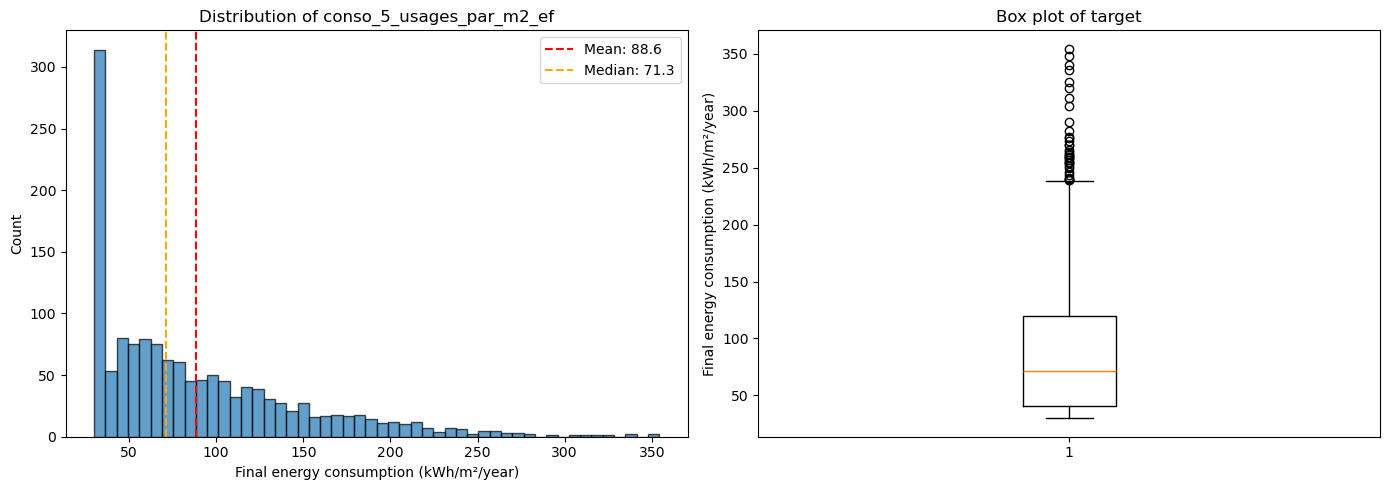

Target stats: mean=88.57, std=59.02, min=30.00, max=354.27


In [14]:
# Distribution of the target variable
y_values = y.values.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_values, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Final energy consumption (kWh/m²/year)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of conso_5_usages_par_m2_ef')
axes[0].axvline(y_values.mean(), color='red', linestyle='--', label=f'Mean: {y_values.mean():.1f}')
axes[0].axvline(np.median(y_values), color='orange', linestyle='--', label=f'Median: {np.median(y_values):.1f}')
axes[0].legend()

axes[1].boxplot(y_values, vert=True)
axes[1].set_ylabel('Final energy consumption (kWh/m²/year)')
axes[1].set_title('Box plot of target')

plt.tight_layout()
plt.show()

print(f"Target stats: mean={y_values.mean():.2f}, std={y_values.std():.2f}, "
      f"min={y_values.min():.2f}, max={y_values.max():.2f}")

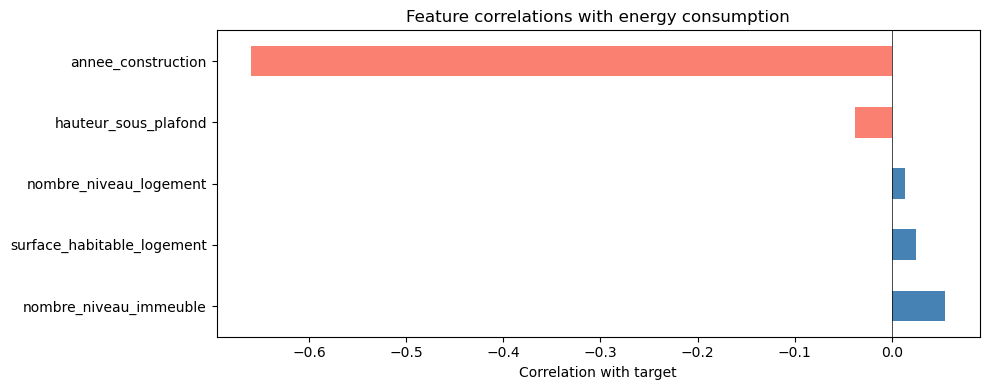

In [15]:
# Correlation of numeric features with the target
numeric_cols = X_df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 0:
    correlations = X_df[numeric_cols].corrwith(
        pd.Series(y_values, index=X_df.index)
    ).sort_values(ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, max(4, len(correlations) * 0.3)))
    correlations.plot(kind='barh', ax=ax, color=['steelblue' if v >= 0 else 'salmon' for v in correlations])
    ax.set_xlabel('Correlation with target')
    ax.set_title('Feature correlations with energy consumption')
    ax.axvline(0, color='black', linewidth=0.5)
    plt.tight_layout()
    plt.show()

# Challenge Evaluation

Submissions are evaluated using **Root Mean Squared Error (RMSE)** as the primary metric:

$$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

where $y_i$ is the true energy consumption and $\hat{y}_i$ is the predicted value.

**Lower RMSE is better.** The leaderboard ranks submissions by RMSE on the public test set. A private test set is used for the final ranking.

**Mean Absolute Error (MAE)** is also computed as a secondary metric for reference:

$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

### Evaluation strategy

The test data is split into:
- **Public test set**: Used for the visible leaderboard during the development phase.
- **Private test set**: Used for the final ranking, hidden until the competition ends.

This prevents overfitting to the public leaderboard.

# Submission Format

Your submission must be a single Python file named **`submission.py`** that defines a function `get_model()`. This function must return a model compatible with the **scikit-learn API** (i.e., it must have `.fit(X, y)` and `.predict(X)` methods).

The ingestion pipeline will:
1. Call `get_model()` to get your model
2. Call `model.fit(X_train, y_train)` with the training data
3. Call `model.predict(X_test)` on the hidden test features

You are free to use any preprocessing, feature engineering, or modeling approach inside your `get_model()` function (e.g., returning a scikit-learn `Pipeline`).

## The submission file

Below is a simple baseline submission. It uses a `Pipeline` with `OrdinalEncoder` for categorical columns and a `RandomForestRegressor`. You can improve this by adding more feature engineering, tuning hyperparameters, or using more powerful models.

In [16]:
# %load solution/submission.py
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder


def get_model():

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OrdinalEncoder(handle_unknown="use_encoded_value",
                                   unknown_value=-1),
             lambda X: X.select_dtypes(include=["object", "category"]).columns.tolist()),
        ],
        remainder="passthrough",
    )

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(
            n_estimators=100, random_state=42
        )),
    ])

    return model

## Local testing pipeline

Here we reproduce the full evaluation pipeline locally: train the model, generate predictions on the public test set, and compute the RMSE score. This lets you validate your submission before uploading to Codabench.

In [17]:
from ingestion_program.ingestion import get_train_data, evaluate_model, clean_features
from scoring_program.scoring import compute_rmse, compute_mae

# 1. Load training data
X_train, y_train = get_train_data("dev_phase/input_data")

# 2. Build and train the model
model = get_model()
model.fit(X_train, y_train.values.ravel())
print(f"Model trained on {X_train.shape[0]} samples with {X_train.shape[1]} features")

# 3. Make predictions on the test set
X_test = pd.read_parquet("dev_phase/input_data/test/test_features.parquet")
X_test = clean_features(X_test)
y_pred = evaluate_model(model, X_test)

# 4. Load ground truth and compute metrics
y_true = pd.read_csv("dev_phase/reference_data/test_labels.csv")

rmse = compute_rmse(y_pred, y_true)
mae = compute_mae(y_pred, y_true)

print(f"\n--- Results on public test set ---")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

Model trained on 1400 samples with 15 features

--- Results on public test set ---
RMSE: 26.0017
MAE:  20.6145


## Submission

To submit your solution on the Codabench platform: